<a href="https://colab.research.google.com/github/olando023/praca-projektowa-/blob/main/praca_projektowa_Medical_Cost_Personal_Datasets_(Insurance_Forecast).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


2: Eksploracja Struktury Danych



In [15]:
print("Informacje o zbiorze danych:")
# Krok 4: Sprawdzenie typów danych i struktury
df.info()

print("\nLiczba brakujących wartości:")
# Krok 5: Weryfikacja braków w danych
print(df.isnull().sum())

Informacje o zbiorze danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Liczba brakujących wartości:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


3: Analiza Kosztów w Zależności od Palenia



Średnie opłaty w zależności od palenia:
smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64


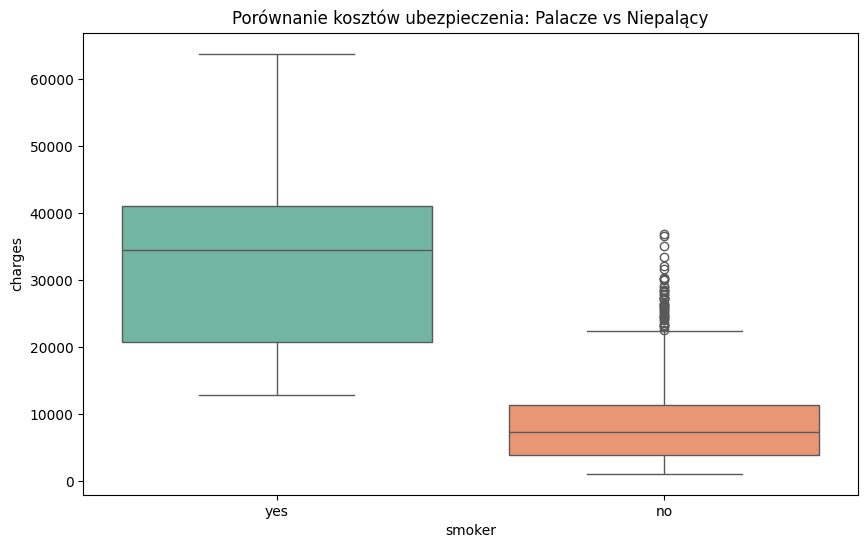

In [16]:
# Krok 6: Obliczenie średnich kosztów dla grup
print("Średnie opłaty w zależności od palenia:")
print(df.groupby('smoker')['charges'].mean())

# Krok 7: Wizualizacja rozkładu kosztów (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df, hue='smoker', palette='Set2', legend=False)
plt.title('Porównanie kosztów ubezpieczenia: Palacze vs Niepalący')
plt.show()

4: Relacja BMI a Koszty



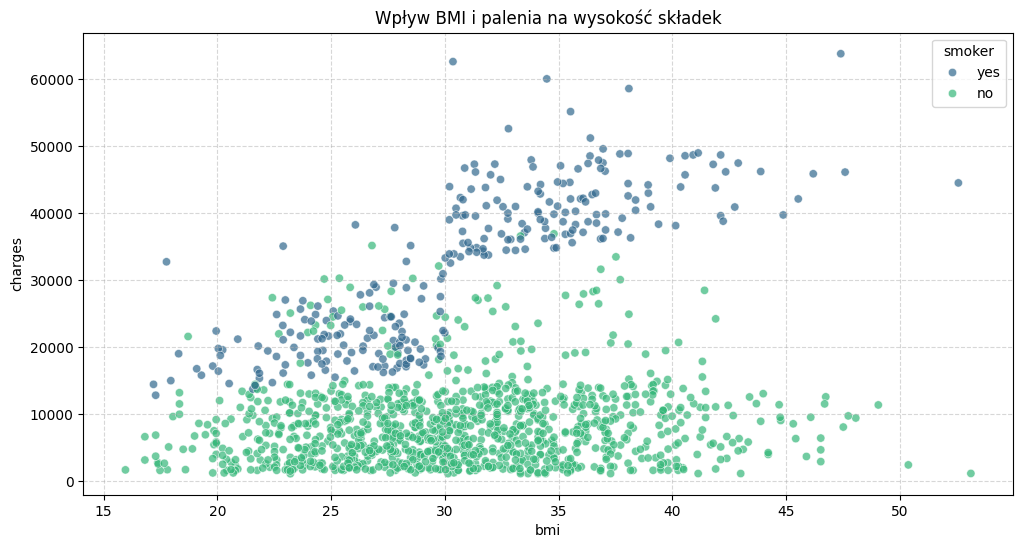

In [17]:
# Krok 8: Analiza korelacji BMI i opłat z podziałem na palaczy
plt.figure(figsize=(12, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.7, palette='viridis')
plt.title('Wpływ BMI i palenia na wysokość składek')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

5: Korelacja


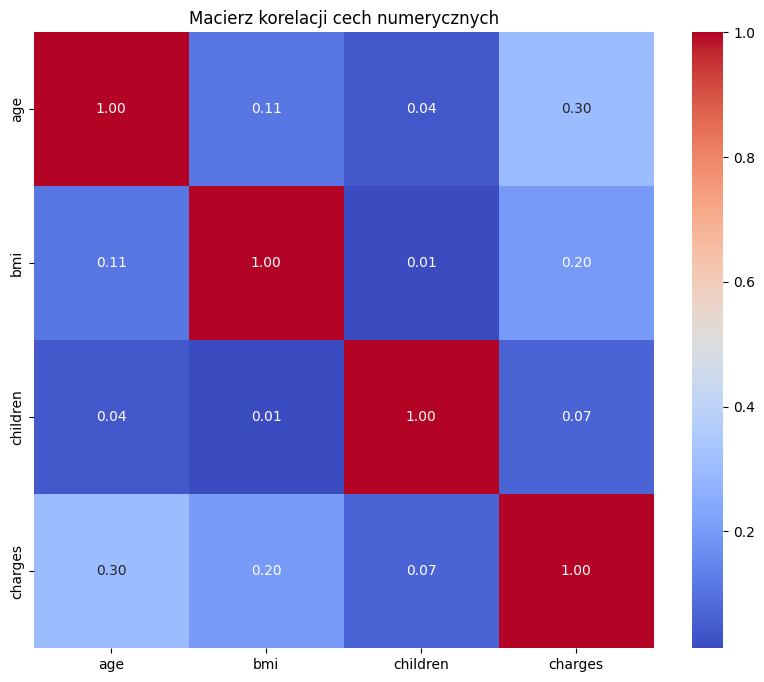

In [18]:
# Krok 9: Obliczenie macierzy korelacji dla cech numerycznych
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=['number']).corr()

# Krok 10: Generowanie mapy ciepła (Heatmap)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji cech numerycznych')
plt.show()

6: Model Random Forest



In [19]:
# Krok 11: Przygotowanie zbiorów X i y
X = df[['age', 'bmi', 'charges']]
y = df['smoker']

# Krok 12: Podział na dane treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Krok 13: Inicjalizacja i trenowanie modelu Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Krok 14: Predykcja i raport klasyfikacji
y_pred_rf = rf_model.predict(X_test)
print("Raport Klasyfikacji - Random Forest:")
print(classification_report(y_test, y_pred_rf))

Raport Klasyfikacji - Random Forest:
              precision    recall  f1-score   support

          no       1.00      0.98      0.99       214
         yes       0.93      1.00      0.96        54

    accuracy                           0.99       268
   macro avg       0.97      0.99      0.98       268
weighted avg       0.99      0.99      0.99       268



7: Macierz Pomyłek RF



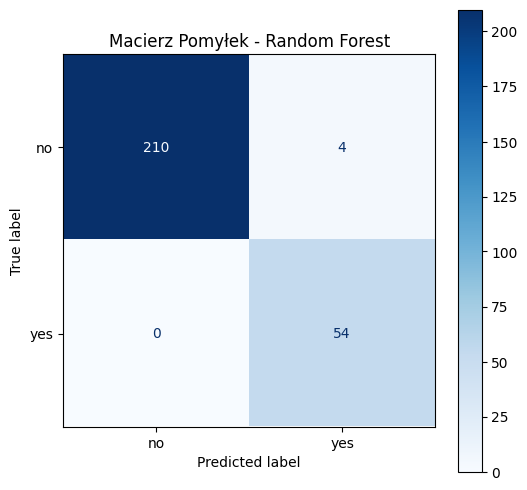

In [20]:
# Krok 15: Obliczenie macierzy pomyłek
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Krok 16: Prezentacja graficzna macierzy pomyłek
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp_rf.plot(cmap='Blues', ax=ax)
plt.title('Macierz Pomyłek - Random Forest')
plt.show()

8: Przygotowanie pod Regresję Logistyczną


In [21]:
# Krok 17: Kodowanie etykiet tekstowych na liczbowe
le = LabelEncoder()
y_encoded = le.fit_transform(df['smoker'])
X_lr = df[['age', 'bmi', 'charges']]

# Krok 18: Podział danych ze stratyfikacją
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Krok 19: Skalowanie cech (standaryzacja)
scaler = StandardScaler()
X_train_lr_sc = scaler.fit_transform(X_train_lr)
X_test_lr_sc = scaler.transform(X_test_lr)

print("Dane przygotowane dla Regresji Logistycznej.")

Dane przygotowane dla Regresji Logistycznej.


9: Model Regresji Logistycznej



Raport Klasyfikacji - Regresja Logistyczna:
              precision    recall  f1-score   support

          no       0.99      0.98      0.98       213
         yes       0.91      0.96      0.94        55

    accuracy                           0.97       268
   macro avg       0.95      0.97      0.96       268
weighted avg       0.97      0.97      0.97       268



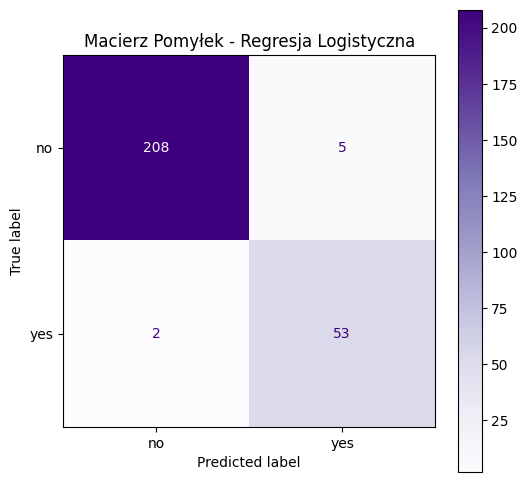

In [22]:
# Krok 20: Trenowanie modelu Regresji Logistycznej
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_lr_sc, y_train_lr)

# Krok 21: Ewaluacja modelu
y_pred_lr = lr_model.predict(X_test_lr_sc)
print("Raport Klasyfikacji - Regresja Logistyczna:")
print(classification_report(y_test_lr, y_pred_lr, target_names=le.classes_))

# Krok 22: Wizualizacja macierzy pomyłek dla regresji
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp_lr.plot(cmap='Purples', ax=ax)
plt.title('Macierz Pomyłek - Regresja Logistyczna')
plt.show()